# Classifier w/ non-linear decision boundary

In [1]:
import matplotlib.pyplot as plt
from trexdiff import Node, relu, sigmoid, log, tensor2d
import numpy as np
import matplotlib

In [2]:

cmap = matplotlib.rcParams['axes.prop_cycle'].by_key()['color']

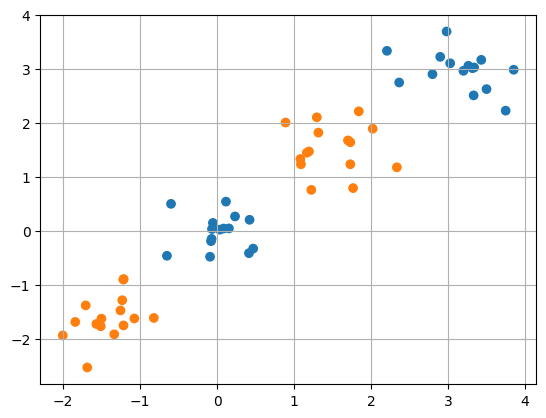

In [3]:
np.random.seed(11)
N = 30
noise_std = 1.5e-1

xs = np.vstack([
    np.random.multivariate_normal([-1.5, -1.5], [[noise_std, 0], [0, noise_std]], size=(N // 2,)),
    np.random.multivariate_normal([0, 0], [[noise_std, 0], [0, noise_std]], size=(N // 2,)),
    np.random.multivariate_normal([1.5, 1.5], [[noise_std, 0], [0, noise_std]], size=(N // 2,)),
    np.random.multivariate_normal([3, 3], [[noise_std, 0], [0, noise_std]], size=(N // 2,)),
])

ys = np.hstack([
    np.ones(N // 2),
    np.zeros(N // 2),
    np.ones(N // 2),
    np.zeros(N // 2),
])

colors = [cmap[int(y)] for y in ys]

plt.scatter(xs[:, 0], xs[:, 1], c=colors)#, edgecolor="black")
plt.grid()

In [4]:
def r01():
    return np.random.normal(0, 1)

In [5]:
N_NEURONS = 15

x = Node(tensor2d(xs))
y = Node(tensor2d(ys.reshape(-1, 1)))

ones = Node(tensor2d.ones(ys.shape[0], 1)) # todo: int-to-node
eps = Node(tensor2d([[1e-7]]))

w0 = Node(tensor2d(np.random.normal(0, 1, size=(2, N_NEURONS))))
w1 = Node(tensor2d(np.random.normal(0, 1, size=(N_NEURONS, 1))))

b0 = Node(tensor2d(np.random.normal(0, 1, size=(1, N_NEURONS))))
b1 = Node(tensor2d(np.random.normal(0, 1, size=(1, 1))))

layer1 = relu(x @ w0 + b0)
logits = layer1 @ w1 + b1
out_sigmoid = sigmoid(logits)

loss = y.T @ log(out_sigmoid + eps) + (ones - y).T @ log(ones - out_sigmoid + eps)

In [6]:
loss.forward()
loss.backward()
loss

Node(val=tensor2d([
  [-158.76]
]), grad=tensor2d([
  [1.00]
]))

In [7]:
lr = 1e-3
#rmsprop decay
decay_rate = 0.9

w0.cache = tensor2d.zeros(2, N_NEURONS)
w1.cache = tensor2d.zeros(N_NEURONS, 1)
b0.cache = tensor2d.zeros(1, N_NEURONS)
b1.cache = tensor2d.zeros(1, 1)

N_iter = 1000
losses = []

for iter in range(N_iter):
    loss.zerograd()
    loss.forward()
    loss.backward()

    for _w in [w0, w1, b0, b1]:
        _w.cache = decay_rate * _w.cache + (1 - decay_rate) * ((_w.grad / N) ** 2)
        _w.val += lr * _w.grad / ((_w.cache ** 0.5) + 1e-8)

    losses.append(-loss.val[0,0])
    
    if iter % 10 == 0:
        print(f"iter {iter}, loss: {-losses[-1]:.6f}")
        

iter 0, loss: -158.758042
iter 10, loss: -31.054372
iter 20, loss: -25.778176
iter 30, loss: -21.691861
iter 40, loss: -18.135247
iter 50, loss: -14.768025
iter 60, loss: -11.781485
iter 70, loss: -9.310147
iter 80, loss: -7.191644
iter 90, loss: -5.557750
iter 100, loss: -4.328705
iter 110, loss: -3.236398
iter 120, loss: -2.558905
iter 130, loss: -2.038534
iter 140, loss: -1.575684
iter 150, loss: -1.321553
iter 160, loss: -1.063928
iter 170, loss: -0.776947
iter 180, loss: -1.158070
iter 190, loss: -0.444617
iter 200, loss: -0.605692
iter 210, loss: -0.322515
iter 220, loss: -0.290761
iter 230, loss: -0.250182
iter 240, loss: -0.203298
iter 250, loss: -0.162539
iter 260, loss: -0.154451
iter 270, loss: -0.144368
iter 280, loss: -0.130094
iter 290, loss: -0.111514
iter 300, loss: -0.109889
iter 310, loss: -0.094534
iter 320, loss: -0.090524
iter 330, loss: -0.084449
iter 340, loss: -0.075791
iter 350, loss: -0.064506
iter 360, loss: -1.904971
iter 370, loss: -0.049343
iter 380, loss:

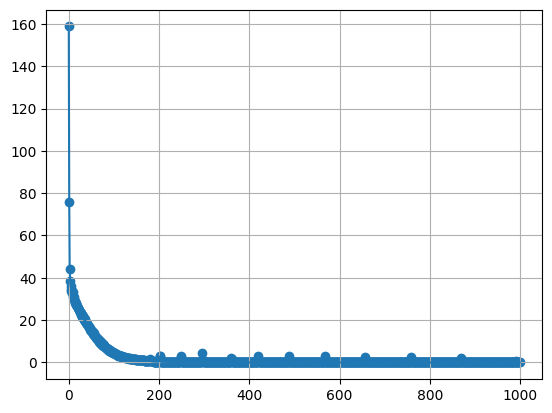

In [8]:
plt.scatter(range(N_iter), losses)
plt.plot(range(N_iter), losses)
plt.grid()

In [9]:
loss.forward()

In [10]:
x.val.shape

(60, 2)

In [11]:
# TODO: implement all of these for tensors
def forward(x):
    _xs = tensor2d(x.tolist())
    _layer1 = (_xs @ w0.val + b0.val).relu()
    _logits = _layer1 @ w1.val + b1.val
    _out_sigmoid = _logits.sigmoid()

    return _out_sigmoid

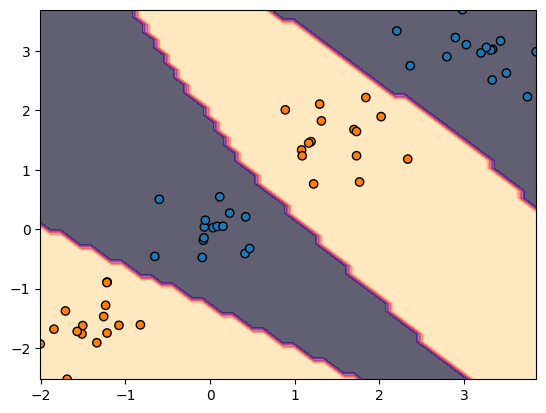

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap


feature_1, feature_2 = np.meshgrid(
    np.linspace(xs[:, 0].min(), xs[:, 0].max()),
    np.linspace(xs[:, 1].min(), xs[:, 1].max())
)
grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T

y_probs = forward(grid).tolist()
y_pred = [1 if x[0] > 0.5 else 0 for x in y_probs]
y_pred = np.reshape(y_pred, feature_1.shape)

display = DecisionBoundaryDisplay(
    xx0=feature_1, xx1=feature_2, response=y_pred,
)
display.plot(
    # cmap=ListedColormap(cmap),
    cmap='magma',
    alpha=0.65,
    # plot_method='pcolormesh'
)
display.ax_.scatter(
    xs[:, 0], xs[:, 1], c=colors, edgecolor="black"
)
plt.show()

/home/tdinev/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


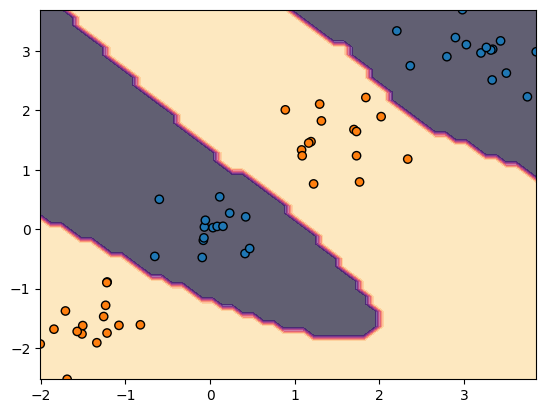

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap


feature_1, feature_2 = np.meshgrid(
    np.linspace(xs[:, 0].min(), xs[:, 0].max()),
    np.linspace(xs[:, 1].min(), xs[:, 1].max())
)
grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T
tree = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, activation='relu').fit(xs, ys)
y_pred = np.reshape(tree.predict(grid), feature_1.shape)

display = DecisionBoundaryDisplay(
    xx0=feature_1, xx1=feature_2, response=y_pred,
)
display.plot(
    # cmap=ListedColormap(cmap),
    cmap='magma',
    alpha=0.65,
    # plot_method='pcolormesh'
)
display.ax_.scatter(
    xs[:, 0], xs[:, 1], c=colors, edgecolor="black"
)
plt.show()